In [1]:
import os
import sys 
sys.path.append("./pd_api_server/api/pdModel/")
from handFeaturesExtraction import *
import json
import joblib
import pandas as pd

import django
import shutil
from asgiref.sync import sync_to_async
import asyncio
from datetime import datetime, timezone
from datetime import timedelta
import numpy as np
import datetime

# Absolute path to your Django project root (adjust this!)
project_path = "/home/pdapp/pd_api_server/"
sys.path.append(project_path)

# Set Django settings
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "mysite.settings")

# Setup Django
django.setup()

from django.contrib.auth.models import User
from api.models import Patient

import numpy as np
import subprocess
import soundfile as sf
import os
import pysptk
from speechScoring import score_pronunciation


def convert_to_wav(input_file):
    output_file = f'{input_file[:-4]}.wav'

    # Run the ffmpeg command as a subprocess
    subprocess.run(["ffmpeg", "-i", input_file, output_file])

    return output_file


def buffer(X, n, p=0, opt=None):
    '''Mimic MATLAB routine to generate buffer array

    MATLAB docs here: https://se.mathworks.com/help/signal/ref/buffer.html

    Parameters
    ----------
    x: ndarray
        Signal array
    n: int
        Number of data segments
    p: int
        Number of values to overlap
    opt: str
        Initial condition options. default sets the first `p` values to zero,
        while 'nodelay' begins filling the buffer immediately.

    Returns
    -------
    result : (n,n) ndarray
        Buffer array created from X
    '''
    import numpy as np

    if opt not in [None, 'nodelay']:
        raise ValueError('{} not implemented'.format(opt))

    i = 0
    first_iter = True
    while i < len(X):
        if first_iter:
            if opt == 'nodelay':
                # No zeros at array start
                result = X[:n]
                i = n
            else:
                # Start with `p` zeros
                result = np.hstack([np.zeros(p), X[:n - p]])
                i = n - p
            # Make 2D array and pivot
            result = np.expand_dims(result, axis=0).T
            first_iter = False
            continue

        # Create next column, add `p` results from last col if given
        col = X[i:i + (n - p)]
        if p != 0:
            col = np.hstack([result[:, -1][-p:], col])
        i += n - p

        # Append zeros if last row and not length `n`
        if len(col) < n:
            col = np.hstack([col, np.zeros(n - len(col))])

        # Combine result with next row
        result = np.hstack([result, np.expand_dims(col, axis=0).T])

    return result


def audio_feature(waveFile):

    y, fs = sf.read(waveFile)
    frameSize = int(0.025 * fs) 
    overlap = frameSize // 2 

    # Normalize audio and convert to mono if needed
    y = y / np.max(np.abs(y)) if np.max(np.abs(y)) > 0 else y
    if y.ndim > 1:
        y = y.mean(axis=1)

    frameMat = buffer(y, frameSize, overlap)
    frameNum = frameMat.shape[1]
    volume1 = np.zeros(frameNum)

    # Compute frame-wise volume
    for i in range(frameNum):
        frame = frameMat[:, i] - np.mean(frameMat[:, i])  # zero-justified
        volume1[i] = np.sum(np.abs(frame))

    # --- threshold ---
    bond = 10

    # --- Pause / Speech frame classification ---
    ave, aveNum, pauseNum = 0, 0, 0
    for v in volume1:
        if v > bond:
            ave += v
            aveNum += 1
        else:
            pauseNum += 1

    volume = ave / aveNum if aveNum > 0 else 0
    
    frame_hop = frameSize - overlap
    frame_hop_duration = frame_hop / fs
    pause = pauseNum * frame_hop_duration
    
    total_duration = len(y) / fs
    pause_percentage = (pause / total_duration) * 100


    # --- Volume change between first and second half ---
    mid = frameNum // 2
    aveF = np.mean(volume1[3:mid][volume1[3:mid] > bond]) if np.any(volume1[3:mid] > bond) else 0
    aveB = np.mean(volume1[mid+1:][volume1[mid+1:] > bond]) if np.any(volume1[mid+1:] > bond) else 0
    volumn_change = ((aveB - aveF) / volume * 100) if volume > 0 else 0

    return volume, pause, pause_percentage, volumn_change



def pitch(x, fs, method='NCF', winLength=400, overlapLength=200):
    hop_length = winLength - overlapLength

    # Pre-emphasis filter
    preemph_coeff = 0.97
    x = np.append(x[0], x[1:] - preemph_coeff * x[:-1])

    if method == 'NCF':
        f0 = pysptk.swipe(x, fs=fs, hopsize=hop_length, min=60, max=400, threshold=0.25, otype="f0")
    elif method == 'ACF':
        f0 = pysptk.rapt(x, fs=fs, hopsize=hop_length, min=60, max=400)
    else:
        raise ValueError('Invalid method')

    return f0
    

def pitch_feature(waveFile):
    x, fs = sf.read(waveFile)
    if x.ndim > 1:
        x = x.mean(axis=1)  # Convert stereo to mono

    # Optional: clip noise (you had this)
    x = np.where(np.abs(x) > 0.2, 0, x)

    # Frame parameters: 25ms frame, 15ms hop
    winLength = int(0.025 * fs)
    overlapLength = int(0.015 * fs)

    f0 = pitch(x, fs, method='NCF', winLength=winLength, overlapLength=overlapLength)

    # Compute volume envelope over same framing
    frameMat = buffer(x, winLength, overlapLength)
    frameNum = frameMat.shape[1]
    volume1 = np.zeros(frameNum)

    for i in range(frameNum):
        frame = frameMat[:, i] - np.mean(frameMat[:, i])
        volume1[i] = np.sum(np.abs(frame))

    # threshold for pause/silence
    bond = 10

    # Mask F0 values where volume is low
    valid_idx = volume1 > bond
    f0[~valid_idx] = np.nan

    # Now compute pitch stats
    f0_clean = f0[~np.isnan(f0)]
    f0_in_range = f0_clean[(f0_clean >= 70) & (f0_clean <= 270)]

    if len(f0_in_range) == 0:
        average_pitch = 0
        pitch_change = 0
    else:
        diffs = np.abs(np.diff(f0_in_range))
        average_pitch = np.mean(f0_in_range)
        pitch_change = np.mean(diffs) if len(diffs) > 0 else 0

    average_vol = np.mean(volume1[valid_idx]) if np.any(valid_idx) else 0

    return average_vol, pitch_change, average_pitch

def voice_features_extraction(voice_file):
    wave_file = f"{voice_file[:-4]}.wav"

    if os.path.isfile(wave_file):
        pass
    else:
        wave_file = convert_to_wav(voice_file)

    volume, pause, pause_percentage, volumn_change = audio_feature(wave_file)
    average_vol, pitch_change, average_pitch = pitch_feature(wave_file)

    score = score_pronunciation(wave_file)
    read_duration = calculate_duration(wave_file)

    return [read_duration, score, pause_percentage, volumn_change, pitch_change, average_pitch]


def calculate_average_volume(file_path):
    audio_data, _ = sf.read(file_path)
    squared_samples = np.square(audio_data)  # Square the audio samples
    mean_squared = np.mean(squared_samples)  # Calculate the mean of squared samples
    root_mean_square = np.sqrt(mean_squared)  # Take the square root to get RMS
    return root_mean_square


def calculate_duration(file_path):
    audio_data, fs = sf.read(file_path)
    total_samples = len(audio_data)  # Number of samples in all channels
    duration = total_samples / fs

    return duration


def sound_checking(voice_file):
    wave_file = f"{voice_file[:-4]}.wav"
    failed_process = False

    if os.path.isfile(wave_file):
        pass
    else:
        wave_file = convert_to_wav(voice_file)

    duration = calculate_duration(wave_file)

    try:
        audio_feature(wave_file)
        average_vol, _, _ = pitch_feature(wave_file)

    except:
        failed_process = True
        average_vol = calculate_average_volume(wave_file)

    return duration, average_vol, failed_process



ImportError: attempted relative import with no known parent package

In [2]:
@sync_to_async
def get_patient_by_name(name):
    patient = Patient.objects.get(name=name)
    return patient

@sync_to_async
def get_patient_related_data(patient):
    user = User.objects.get(username=patient.user_name)
    
    data = {
        "date_join":user.date_joined,
        "patient": {
            "id": patient.patientId,
            "name": patient.name,
            "user_name": patient.user_name,
            "email": patient.email,
            "phone_no": patient.phone_no,
            "id_no": patient.id_no,
            "gender": patient.gender,
            "age": patient.age,
            "birthday": patient.birthday,
        },
        "records": [],
        "uploaded_files": [],
        "results": [],
        "questionnaires": [],
    }

    for r in patient.patientrecord_set.all():
        data["records"].append({
            "time": r.time,
            "taking_pd_medicine": r.taking_pd_medicine,
            "taking_pd_med3hr": r.taking_pd_med3hr,
        })

    for f in patient.fileuploaded_set.all():
        data["uploaded_files"].append({
            "upload_time": f.upload_time,
            "file_type": f.file_type,
            "file_path": f.file_path,
        })

    for res in patient.results_set.all():
        data["results"].append({
            "upload_time": res.upload_time,
            "gait_result": res.gait_result,
            "voice_result": res.voice_result,
            "hand_result": res.hand_result,
            "multimodal_results": res.multimodal_results,
        })

    for q in patient.patientquestionairerecord_set.all():
        data["questionnaires"].append({
            "time": q.time,
            "riskMarker": q.riskMarker,
            "PLR": q.PLR,
            "TELR": q.TELR,
            "PostProb": q.PostProb,
            "PPPD": q.PPPD,
            "response": q.response,
        })

    return data


def get_latest_folders(directory, top_k=1):
    # List all folders in the given directory
    folders = [
        os.path.join(directory, d)
        for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ]
    
    # Sort folders by creation time (newest first)
    folders.sort(key=lambda x: os.path.getctime(x), reverse=True)
    
    return folders[:top_k]


def deploy(data, feature_idx_dt, modal="gait", fold=10):
    save_file_dir = f"{MODEL_PATHS}Save_model_{modal}/"
    proba_out_dt = {}
    
    for model_name in TRAINED_MODELS_LS:
        proba_ls = []

        for i in range(fold):

            clf_pth = f'{save_file_dir}{i}_{model_name}.joblib'
            print(print(clf_pth))
            clf = joblib.load(clf_pth)
            f_idx = feature_idx_dt[model_name]
            predict_proba = clf.predict_proba(data[:, f_idx])
            proba_ls.append(predict_proba)

        mean_test = np.array(proba_ls).mean(0)
        proba_out_dt[model_name] = mean_test[:, 1]

    return proba_out_dt


async def get_data(pid, all_npy_dt, hand_features_dt="", audio_features_dt=""):
    P = await get_patient_by_name(pid)
    age = P.age 
    gender = P.gender

    if gender == 2:
        gender = 0

    gait_len = len(gait_feature_name)
    hand_len = len(hand_features_name)
    voice_len = len(voice_feature_name)

    gait_result = {}
    hand_result = {}
    voice_result = {}
    all_result = {}

    for r in [gait_result, hand_result, voice_result, all_result]:
        for k in TRAINED_MODELS_LS:
            r[k] = [0, 0]

    data = np.load(all_npy_dt[pid])

    gait_feature = np.concatenate([np.array([age, gender]), data[:gait_len]])
    
    if audio_features_dt:
        voice_feature = np.concatenate([np.array([age, gender]), audio_features_dt[pid]])
    else:
        voice_feature = np.concatenate([np.array([age, gender]), data[-voice_len:]])
        
    if hand_features_dt:
        
        hand_feature = np.concatenate([np.array([age, gender]), hand_features_dt[pid]])
    else:
        hand_feature = np.concatenate([np.array([age, gender]), data[gait_len:voice_len]])
    
    return gait_feature, voice_feature, hand_feature


async def get_voice_feature(p_name):
    
    P = await get_patient_by_name(p_name)
    data = await get_patient_related_data(P)

    for file in data['uploaded_files']:
        if file["file_type"] == "sound" and "freetalk" not in file["file_path"]:
            sound_file = file["file_path"]
            pth = "/mnt/pd_app/sound/"
            
            return voice_features_extraction(pth+sound_file)


def get_predict(gait_feature, voice_feature, hand_feature):
     
    sfs_idx = joblib.load(f'{MODEL_PATHS}nvp_sfs_idx.txt')
    
    gait_result = deploy(np.array([gait_feature]), sfs_idx['gait_sfs_idx'], modal="gait", fold=10)
    hand_result = deploy(np.array([hand_feature]), sfs_idx['hand_sfs_idx'], modal="hand", fold=10)
    voice_result = deploy(np.array([voice_feature]), sfs_idx['voice_sfs_idx'], modal="voice", fold=10)

    weight = [5, 4, 6]

    all_result = {}

    for k in TRAINED_MODELS_LS:
        all_result[k] = np.average(np.array([[gait_result[k]], [hand_result[k]],
                                             [voice_result[k]]]), weights=weight, axis=0)[0]

    results = np.array([gait_result["RF"][0], hand_result["RF"][0], voice_result["RF"][0],
                        all_result["RF"][0]]) * 100
    return results


MODEL_PATHS = "/home/pdapp/pd_api_server/api/pdModel/PD_pretrained_models/"
TRAINED_MODELS_LS = ["RF"]  # remove KNN, "GBM", "LightGBM", "C4.5 DT", "LogReg", "NB", "SVM", "AdaBoost",

gait_feature_name = ['left_foot_ground', 'right_foot_ground', 'left_right_foot_len_average', 'left_right_foot_len_max',
                     'left_turning_duration', 'left_turning_slope', 'right_turning_duration', 'right_turning_slope',
                     'l_leg_max_angles', 'l_leg_min_angles', 'r_leg_max_angles', 'r_leg_min_angles', 'l_arm_max_angles',
                     'l_arm_min_angles', 'r_arm_max_angles', 'r_arm_min_angles', 'core_max_angles', "core_min_angles",
                     'average_duration_per_rounds', "duration_change", "l_mean_steps", "r_mean_steps"]

hand_features_name = [ "Right Tapping Time", "Right Tapping Time Change", "Right Tapping Distance", "Left Tapping Time",
                       "Left Tapping Time Change", "Left Tapping Distance", "Left Tapping Frequency", 
                       "Left Tapping Intensity", "Left Tapping Power", "Left Tapping Frequency Change",
                       "Right Tapping Frequency", "Right Tapping Intensity", "Right Tapping Power", "Right Tapping Frequency Change"]

voice_feature_name = ['reading_time' , 'score', 'pause(%)', 'volume change', 'pitch change', 'Average pitch']

In [17]:
import joblib
import numpy as np
import os

joblib.load("./pd_api_server/api/pdModel/PD_pretrained_models/nvp_sfs_idx.txt")


arr = np.load("/mnt/pd_app/results/20250721_122959/2025-07-21_12:48:24/all_feature.npy")


gait_feature_name = ['left_foot_ground', 'right_foot_ground', 'left_right_foot_len_average', 'left_right_foot_len_max',
                     'left_turning_duration', 'left_turning_slope', 'right_turning_duration', 'right_turning_slope',
                     'l_leg_max_angles', 'l_leg_min_angles', 'r_leg_max_angles', 'r_leg_min_angles', 'l_arm_max_angles',
                     'l_arm_min_angles', 'r_arm_max_angles', 'r_arm_min_angles', 'core_max_angles', "core_min_angles",
                     'average_duration_per_rounds', "duration_change", "l_mean_steps", "r_mean_steps"]

hand_features_name = [ "Right Tapping Time", "Right Tapping Time Change", "Right Tapping Distance", "Left Tapping Time",
                       "Left Tapping Time Change", "Left Tapping Distance", "Left Tapping Frequency", 
                       "Left Tapping Intensity", "Left Tapping Power", "Left Tapping Frequency Change",
                       "Right Tapping Frequency", "Right Tapping Intensity", "Right Tapping Power", "Right Tapping Frequency Change"]

voice_feature_name = ['reading_time' , 'score', 'pause(%)', 'volume change', 'pitch change', 'Average pitch']

arr

array([ 3.22459893e-01,  2.28877005e-01,  2.27516683e+01,  7.69573569e+01,
        5.35000000e+00, -2.11300475e-02,  4.06666667e+00, -1.68983913e-02,
        5.73146000e+01,  8.43100000e-01,  5.73241000e+01,  1.84396000e+01,
        5.67971000e+01,  2.58000000e-02,  5.73161000e+01,  7.72000000e-02,
        5.73185000e+01,  7.90000000e-03,  1.00277778e+01, -2.38260432e-02,
        5.66666667e+00,  6.50000000e+00,  4.71764118e-01,  4.31034483e-02,
        7.11412033e-02,  4.00228740e+00,  8.67583832e-01,  3.47231984e+00,
        5.06196400e-02,  4.59270365e-01, -8.62068966e-04,  9.51958690e-02,
        2.84802521e+00,  1.35375594e+00,  3.85553103e+00, -5.91333654e-01,
        7.44960000e+01,  9.71408000e+01,  4.79220361e+01,  7.19494305e+00,
        2.90922955e+00,  1.37663528e+02])

In [3]:
# path="/mnt/pd_app/results/"
# hand_features_dt = {}
# all_npy_dt = {}

# for _dir in os.listdir(path):

#     lastest_dir = get_latest_folders(path+_dir, top_k=1)
    
#     if lastest_dir: 
#         folder_pth = lastest_dir[0]
        
#         if os.path.isfile(folder_pth+"/"+"all_feature.npy"):
#             all_npy_dt[_dir] = folder_pth+"/"+"all_feature.npy"
            
#         for items in os.listdir(folder_pth):
#             if items[-3:] == 'txt':
#                 if "left" in items:
#                     left_hand_txt = items
#                 else:
#                     right_hand_txt = items
        
#         try:

#             hand_features = single_thumb_index_hand(folder_pth+"/"+right_hand_txt, folder_pth+"/"+left_hand_txt)
#             hand_features_dt[_dir] = hand_features
#         except:
#             print(_dir)

#         left_hand_txt = ""
#         right_hand_txt = ""
        
# # Save dictionary
# with open('hand_features_20250515.json', 'w') as f:
#     json.dump(hand_features_dt, f)

In [4]:
path="/mnt/pd_app/results/"
audio_features_dt = {}
audio_error = []

for _dir in os.listdir(path):
    lastest_dir = get_latest_folders(path+_dir, top_k=1)
    if lastest_dir: 
        folder_pth = lastest_dir[0]
        try:
            audio_features_dt[_dir] = await get_voice_feature(_dir)
        except:
            print(_dir)
            
# Save dictionary
with open('voice_features_20250605_bond10.json', 'w') as f:
    json.dump(audio_features_dt, f)

test001
test
Leo


ffmpeg version 3.4.11-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 7 (Ubuntu 7.5.0-3ubuntu1~18.04)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --enable-gpl --disable-stripping --enable-avresample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librubberband --enable-librsvg --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvorbis --enable-libvpx --enable-libwavpack --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-li

蔡薇君
test004
002-20250317-10
NTUH 002_20250317_008


In [5]:
with open('voice_features_20250527_bond10.json', 'r') as f:
    dt = json.load(f)
    f.close()
dt

{'008_20250319_1': [57.664,
  97.873,
  41.05681187569367,
  -5.657892850272103,
  3.9522356554445572,
  186.10367340893274],
 '20250512_112822': [67.2,
  96.9706,
  31.268601190476193,
  -13.017986382914918,
  5.862001916317384,
  185.4569248671201],
 '20250513_155455': [46.72,
  98.609,
  40.31999143835617,
  -13.264104675933408,
  6.000674759933585,
  191.51109184775427],
 'NTUH002_20250306_2': [48.576,
  96.4275,
  35.40843214756258,
  5.37457659231697,
  11.375761268115875,
  113.74269494124069],
 '20250415_154810': [71.936,
  97.9292,
  42.103397464412815,
  -10.228207128771976,
  4.563192903004324,
  188.86493737479498],
 '20250505_092919': [63.232,
  93.9734,
  36.433293269230774,
  -1.1690019402053131,
  4.548574296185614,
  170.60607603208857],
 '20250425_152013': [47.616,
  97.2952,
  37.95992943548387,
  -7.095323461872205,
  4.372347394455508,
  150.05425049231005],
 '20250508_134654': [61.376,
  98.4315,
  40.651068821689265,
  6.36292411276294,
  4.333465774724619,
  148

<Axes: xlabel='duration', ylabel='pause percentage'>

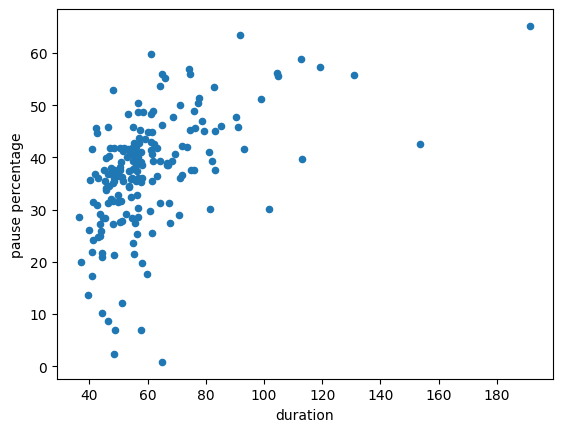

In [6]:
df = pd.DataFrame.from_dict(dt).T
df.columns = ["duration", "score", "pause percentage", "volume change", "pitch change", "pitch"]
df.plot.scatter("duration", "pause percentage")

In [5]:
# with open("./20250505_hand_tapping.json", "w") as f:
#     json.dump(hand_features_dt, f)

In [6]:
# all_gait_dt = {}
# all_hand_dt = {}
# all_voice_dt = {}
# error_pid = []

# for pid in list(hand_features_dt.keys()):
#     try:
#         gait_feature, voice_feature, hand_feature = await get_data(pid, all_npy_dt,
#                                                                    hand_features_dt = hand_features_dt,
#                                                                   audio_features_dt = audio_features_dt)
#         all_gait_dt[pid] = gait_feature
#         all_hand_dt[pid] = hand_feature
#         all_voice_dt[pid] = voice_feature
        
#     except:
#         print(f"Error processing {pid}")
#         error_pid.append(pid)

In [7]:
# Save dictionary
with open('voice_features_20250515.json', 'r') as f:
    audio_features_dt = json.load(f)
df = pd.DataFrame.from_dict(audio_features_dt).T
print(df.iloc[:,2].describe())
print(df.iloc[:,2].unique())

count    155.000000
mean      20.011813
std        0.007431
min       20.000000
25%       20.005441
50%       20.011281
75%       20.017387
max       20.029048
Name: 2, dtype: float64
[20.00815067 20.01488095 20.01284247 20.02017457 20.00041704 20.00569332
 20.00378024 20.02004041 20.0169748  20.00518838 20.00212919 20.00188253
 20.00762195 20.00693947 20.01096491 20.02640845 20.02384142 20.0035082
 20.00596788 20.00495569 20.02186752 20.00117481 20.01567785 20.01779359
 20.01265405 20.02014237 20.01549587 20.01851611 20.02472573 20.00651796
 20.01067236 20.00098892 20.00799705 20.01732183 20.00107388 20.01092176
 20.02011323 20.02146631 20.0084246  20.00343407 20.00855327 20.01499613
 20.00577017 20.00352633 20.02432504 20.02710684 20.02407039 20.00473485
 20.01741748 20.01683356 20.00823425 20.02106191 20.02501756 20.01128072
 20.0079126  20.00218115 20.00039507 20.00454362 20.00505391 20.0001631
 20.00950336 20.01953125 20.0073519  20.00762195 20.00633446 20.02008675
 20.01175832 20

In [8]:
all_results_dt = {}
error_pid = []
for pid in list(hand_features_dt.keys()):
    try:
        gait_feature, voice_feature, hand_feature = await get_data(pid, all_npy_dt,
                                                                   hand_features_dt = hand_features_dt,
                                                                  audio_features_dt = audio_features_dt)
        
        results = get_prediction(gait_feature, voice_feature, hand_feature)
        all_results_dt[pid] = results
    except:
        print(f"Error processing {pid}")
        error_pid.append(pid)

df = pd.DataFrame.from_dict(all_results_dt).T
df.to_csv("./20250515_predict_results.csv")

NameError: name 'hand_features_dt' is not defined

In [ ]:
error_pid    

In [11]:
import cv2 

In [14]:
cap = cv2.VideoCapture('/mnt/pd_app/gesture/2025-04-29 16:02:00_gesture_20250429_154157__153_右手_REC_9EF475A1-0CCF-4F99-B72B-CA6612C3F385.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
fps

29.866553696250794

In [ ]:
# import pandas as pd

# data = {
#     'index': [
#         '003_20250313_4', '004_20250313_1', '004_20250313_2', '004_20250313_3', '004_20250313_8',
#         '004-20250313_07', '008_20250319_1', '008_20250319_2', '20250326_143045', '20250327_091551',
#         '20250327_094148', '20250327_102000', '20250327_114817', '20250331_102957', '20250331_110845',
#         '20250331_113859', '20250331_134903', '20250331_140420', '20250331_143828', '20250331_152729',
#         '20250331_160904', '20250331_165049', '20250401_140936', '20250401_145545', '20250401_153600',
#         '20250401_162029', '20250401_162100', '20250402_155030', '20250402_161217', '20250407_092454',
#         '20250407_103556', '20250407_114410', '20250407_121337', '20250407_135508', '20250407_151015',
#         '20250407_160315', '20250408_134919', '20250408_144856', '20250408_152403', '20250410_091358',
#         '20250410_103854', '20250410_111659', '20250410_114258', '20250410_122054', '20250410_130730',
#         '20250411_134712', '20250411_150142', '20250411_154512', '20250411_162808', '20250414_102022',
#         '20250414_104654', '20250414_111637', '20250414_115010', '20250414_123736', '20250414_134215',
#         '20250414_141512', '20250414_144409', '20250414_144804', '20250414_155148', '20250415_151810',
#         '20250415_154810', '20250417_093409', '20250417_100041', '20250417_101337', '20250417_105354',
#         '20250417_112311', '20250417_121548', '20250417_123946', '20250417_125540', '20250417_133033',
#         '20250417_151025', '20250418_142843', '20250418_154150', '20250421_092515', '20250421_100525',
#         '20250421_105249', '20250421_112107', '20250421_115147', '20250421_135406', '20250421_145854',
#         '20250422_143040', '20250422_154353', '20250422_161104', '20250423_151826', '20250424_090936',
#         '20250424_110902', '20250424_113908', '20250424_115815', '20250424_122412', '20250424_124909',
#         '20250424_132509', '20250425_141922', '20250425_152013', '20250428_144203', '20250428_153226',
#         '20250429_142745', '20250429_154157', '20250505_092919', '20250505_114207', '20250505_123651',
#         '20250505_135432', '20250505_145451', 'NTUH 002_20250317_007', 'NTUH 002_20250317_009',
#         'NTUH_20250306_1', 'NTUH002 _20250317_005', 'NTUH002_20250303_1', 'NTUH002_20250303_2',
#         'NTUH002_20250303_3', 'NTUH002_20250303_4', 'NTUH002_20250306_2', 'NTUH002_20250306_3',
#         'NTUH002_20250306_4', 'NTUH002_20250306_5', 'NTUH002_20250306_6', 'NTUH002_20250306_7',
#         'NTUH002_20250310_1', 'NTUH002_20250310_2', 'NTUH002_20250310_3', 'NTUH002_20250310_4',
#         'NTUH002_20250317_01', 'ntuh002_20250317_4', 'NTUH008_20250305_1', 'NTUH008_20250312_1'
#     ],
#     'PD': [
#         3, 2, 1, 2, 2, 4, 2, 3, 1, 0, 0, 0, 0, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
#         3, 4, 3, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1, 3, 1, 0, 0, 0, 0, 0, 0, 3, 1, 1, 1, 0, 0, 0, 0, 0,
#         0, 2, 2, 1, 2, 4, 1, 2, 1, 4, 1, 0, 0, 3, 4, 1, 3, 1, 0, 0, 0, 0, 0, 3, 2, 3, 0, 4, 3, 4,
#         2, 0, 0, 1, 3, 3, 0, 0, 1, 3, 3, 3, 1, 2, 0, 2, 2, 3, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3,
#         4, 1, 3, 2
#     ]
# }

# df = pd.DataFrame.from_dict(data)
# df = df.set_index("index")


In [ ]:
# gait_df = pd.DataFrame.from_dict(all_gait_dt).T
# gait_df = gait_df.reset_index().set_index("index")
# gait_df = pd.concat([gait_df, df], axis=1).dropna()
# gait_df.to_csv("./20250513_gait.csv")

In [ ]:
# hand_df = pd.DataFrame.from_dict(all_hand_dt).T
# hand_df = hand_df.reset_index().set_index("index")
# hand_df = pd.concat([hand_df, df], axis=1).dropna()
# hand_df.to_csv("./20250513_hand.csv")

# voice_df = pd.DataFrame.from_dict(all_voice_dt).T
# voice_df = voice_df.reset_index().set_index("index")
# voice_df = pd.concat([voice_df, df], axis=1).dropna()
# voice_df.to_csv("./20250513_voice.csv")